In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('retail_sales_dataset.csv') 
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [7]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [8]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


In [9]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()  # check karo Date ab datetime type ban gayi hai

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


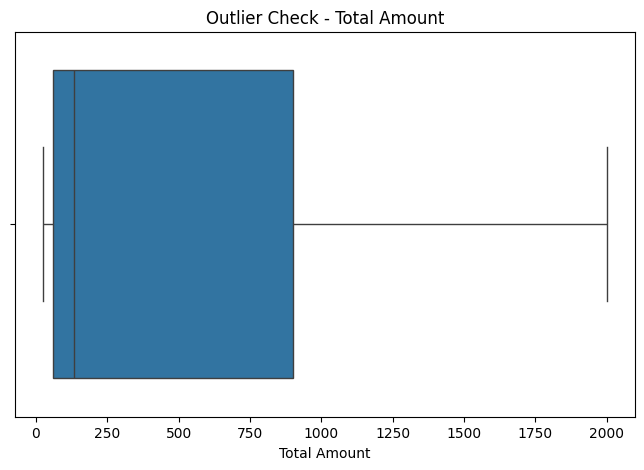

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total Amount'])
plt.title('Outlier Check - Total Amount')
plt.show()

In [12]:
print("Total Revenue:", df['Total Amount'].sum())
print("Total Transactions:", df['Transaction ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())

Total Revenue: 456000
Total Transactions: 1000
Total Customers: 1000


In [13]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print(category_sales)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [14]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()
print(gender_sales)


Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


In [15]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()
print(monthly_sales)

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


In [16]:
df['Age Group'] = pd.cut(df['Age'], bins=[0,20,30,40,50,60,100], 
                          labels=['<20','20-30','30-40','40-50','50-60','60+'])
age_sales = df.groupby('Age Group')['Total Amount'].sum()
print(age_sales)

Age Group
<20       34730
20-30     98215
30-40     95950
40-50     93795
50-60    100085
60+       33225
Name: Total Amount, dtype: int64


In [17]:
df[['Age','Quantity','Price per Unit','Total Amount']].corr()

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


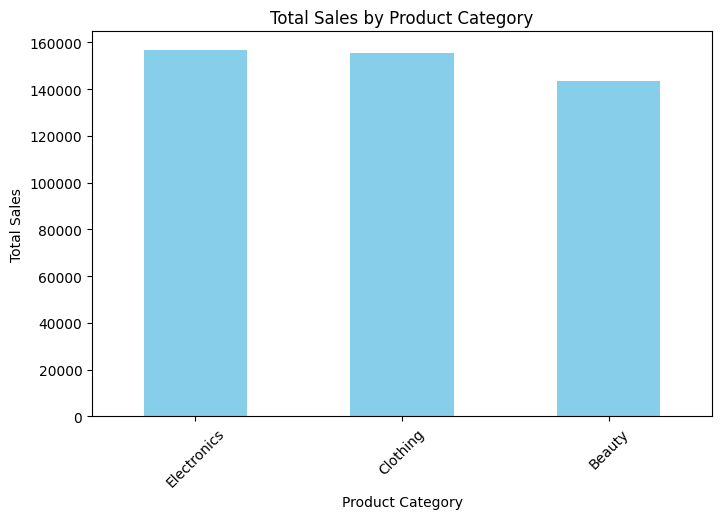

In [18]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

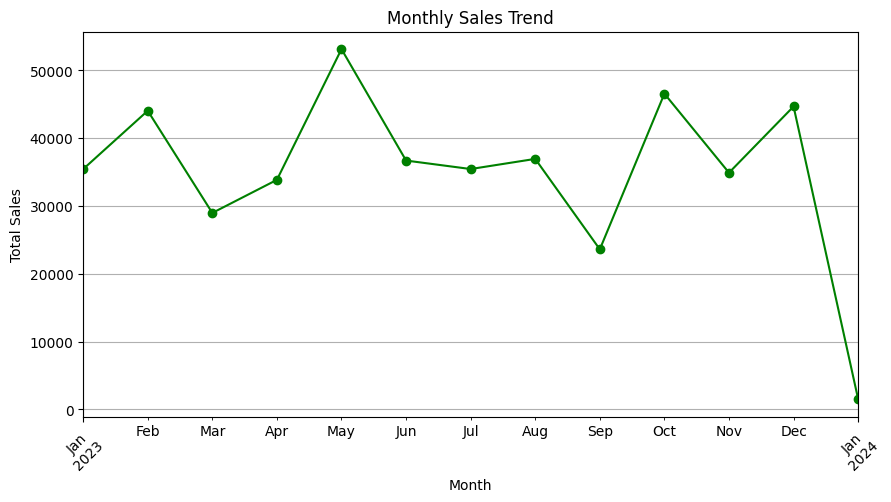

In [19]:
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

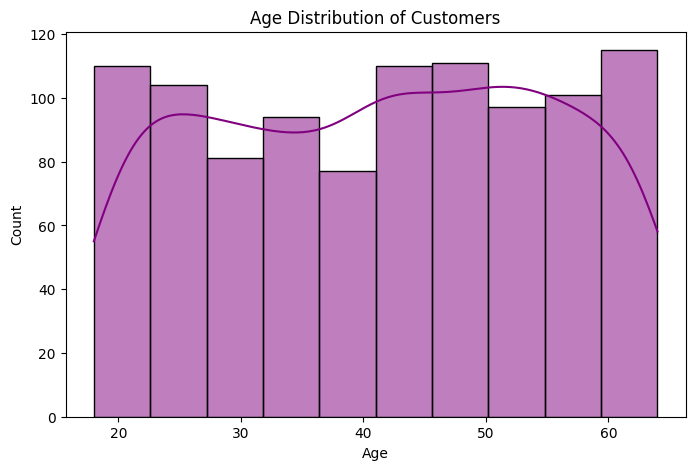

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True, color='purple')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

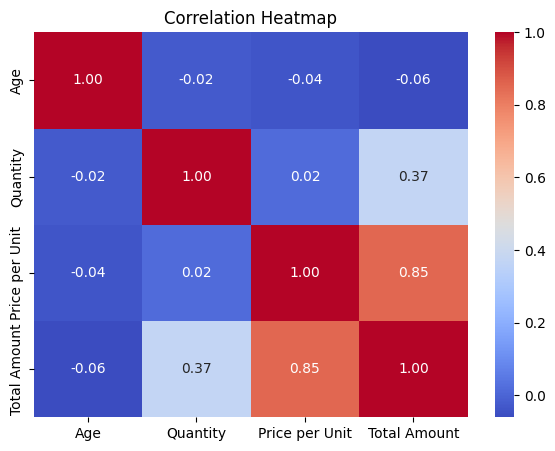

In [21]:
plt.figure(figsize=(7,5))
sns.heatmap(df[['Age','Quantity','Price per Unit','Total Amount']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

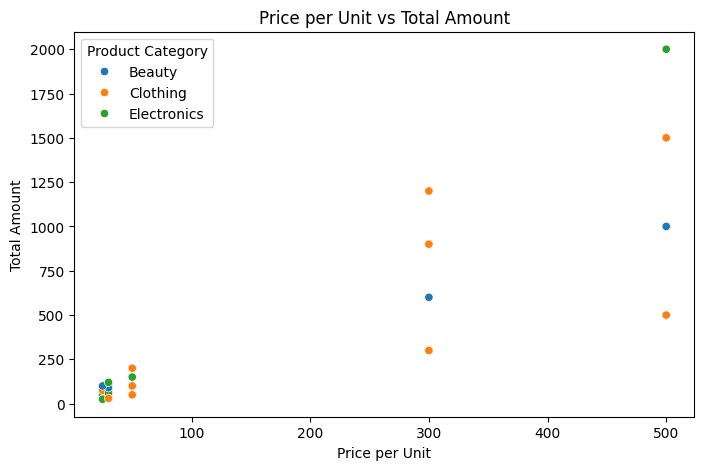

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Price per Unit', y='Total Amount', hue='Product Category', data=df)
plt.title('Price per Unit vs Total Amount')
plt.show()

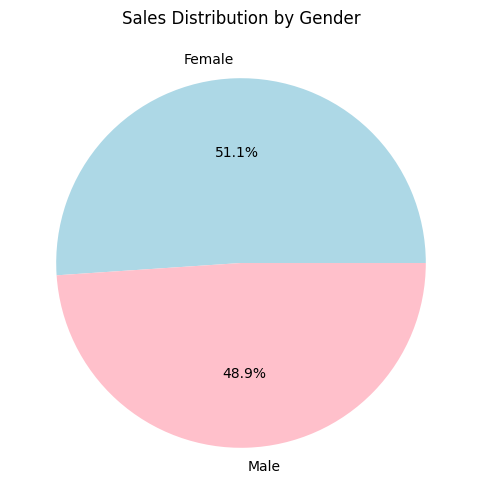

In [23]:
plt.figure(figsize=(6,6))
gender_sales.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue','pink'])
plt.title('Sales Distribution by Gender')
plt.ylabel('')
plt.show()
